# Khai Phá Dữ Liệu (Exploratory Data Analysis)


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)


In [37]:
# Load the raw dataset (to analyze raw Amount and Time)
df = pd.read_csv('creditcard.csv')
display(df.head())


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [38]:
df[['Class', 'Amount', 'Time']].describe()


,Class,Amount,Time
count,284807.000000,284807.000000,284807.000000
mean,0.001727,88.349619,94813.859575
std,0.041527,250.120109,47488.145955
min,0.000000,0.000000,0.000000
25%,0.000000,5.600000,54201.500000
50%,0.000000,22.000000,84692.000000
75%,0.000000,77.165000,139320.500000
max,1.000000,25691.160000,172792.000000


### Kiểm tra thông tin tập dữ liệu


Số lượng giao dịch:
Bình thường (0): 284315 
Gian lận (1): 492


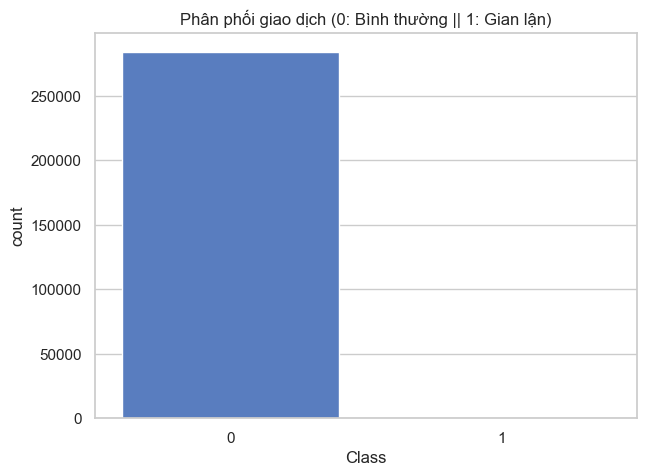

In [39]:
# Đếm số lượng lớp (Class)
class_counts = df['Class'].value_counts()
print("Số lượng giao dịch:\nBình thường (0):", class_counts[0], "\nGian lận (1):", class_counts[1])

plt.figure(figsize=(7, 5))
sns.countplot(x='Class', data=df)
plt.title('Phân phối giao dịch (0: Bình thường || 1: Gian lận)')
plt.show()


### Phân phối của Amount và Time


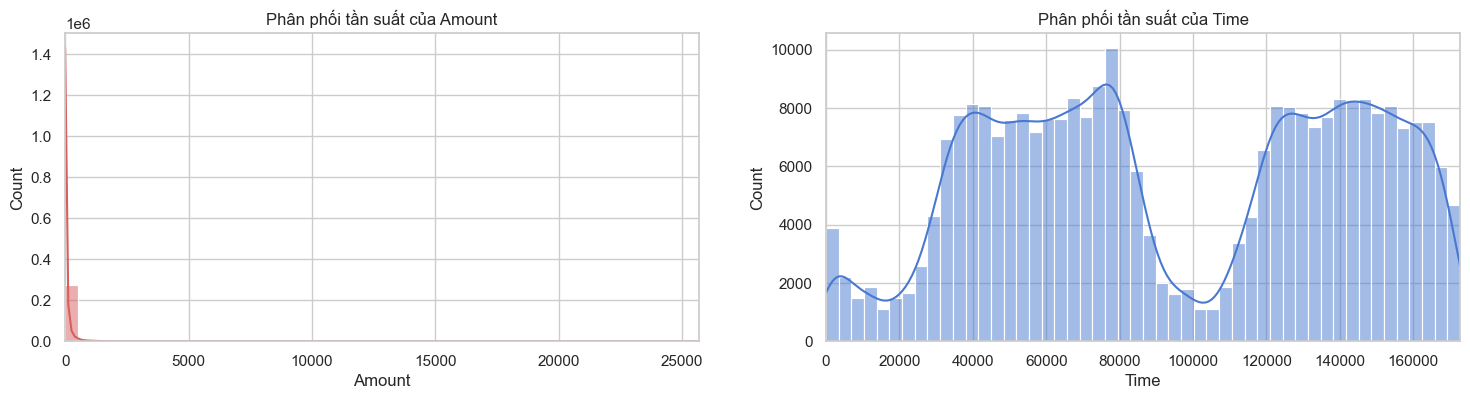

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))
sns.histplot(df['Amount'], bins=50, ax=ax[0], color='r', kde=True)
ax[0].set_title('Phân phối tần suất của Amount')
ax[0].set_xlim([min(df['Amount']), max(df['Amount'])])

sns.histplot(df['Time'], bins=50, ax=ax[1], color='b', kde=True)
ax[1].set_title('Phân phối tần suất của Time')
ax[1].set_xlim([min(df['Time']), max(df['Time'])])
plt.show()


### Phân tích hệ số tương quan


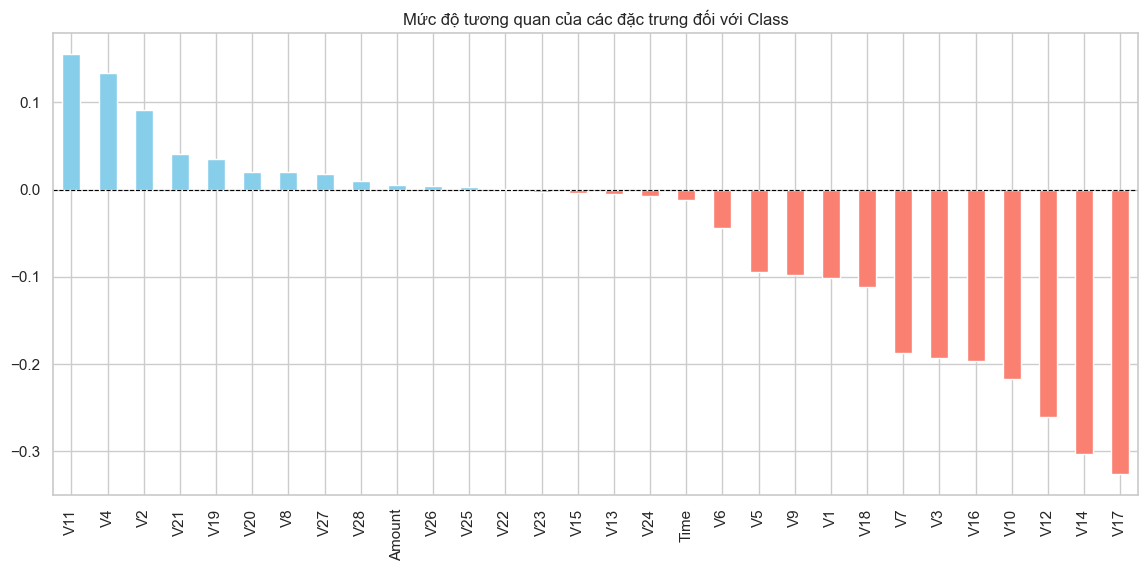

In [41]:
corr_matrix = df.corr()
class_corr = corr_matrix['Class'].drop('Class')
class_corr_sorted = class_corr.sort_values(ascending=False)

plt.figure(figsize=(14, 6))
colors = ['salmon' if c < 0 else 'skyblue' for c in class_corr_sorted.values]
class_corr_sorted.plot(kind='bar', color=colors)
plt.title('Mức độ tương quan của các đặc trưng đối với Class')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.show()


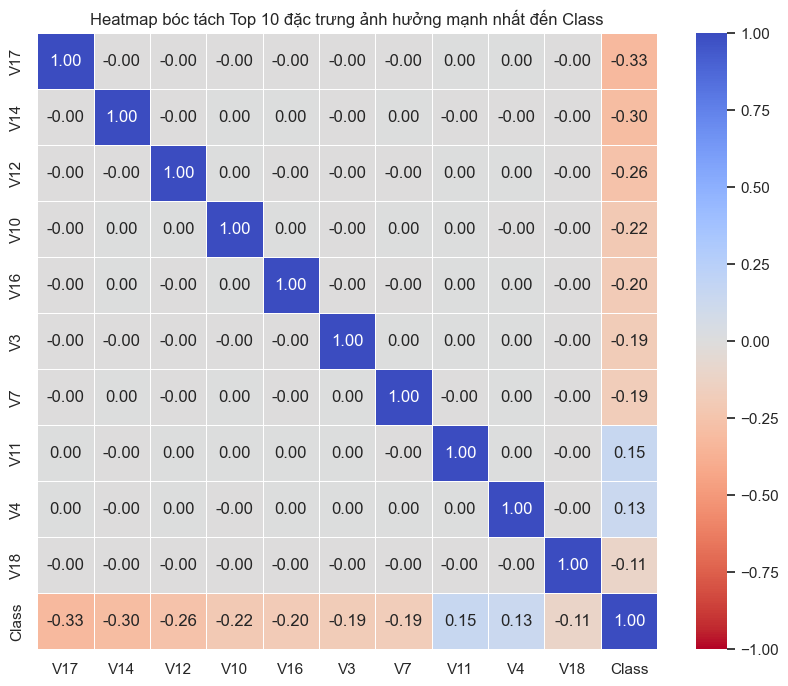

In [42]:
# Lấy ra Top 10 đặc trưng có mức độ tương quan lớn nhất với Class
top_10_features = abs(class_corr).sort_values(ascending=False).head(10).index.tolist()
top_10_features.append('Class')

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_10_features].corr(), cmap='coolwarm_r', annot=True, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap bóc tách Top 10 đặc trưng ảnh hưởng mạnh nhất đến Class')
plt.show()


### Boxplots & KDE cho các Feature quan trọng


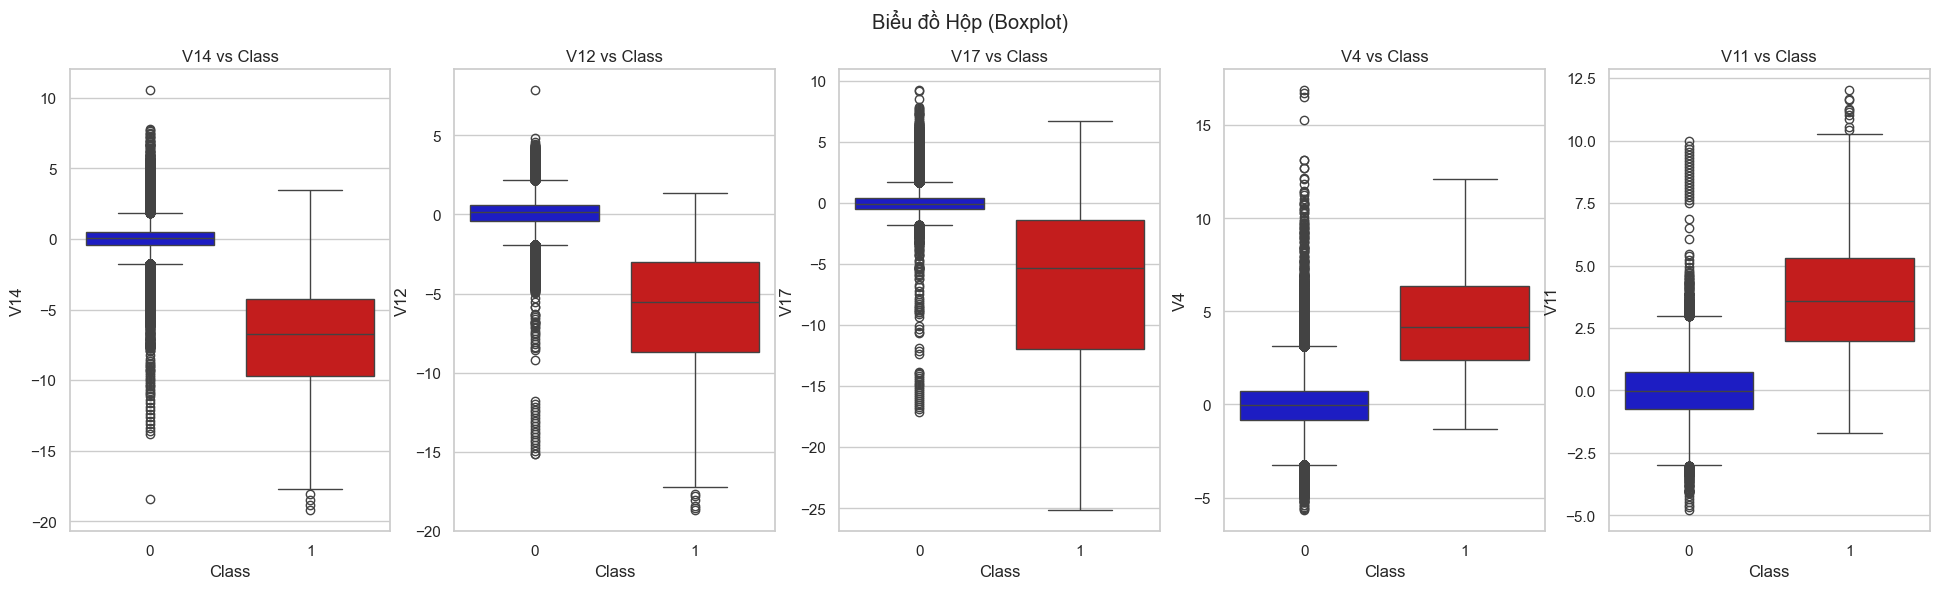

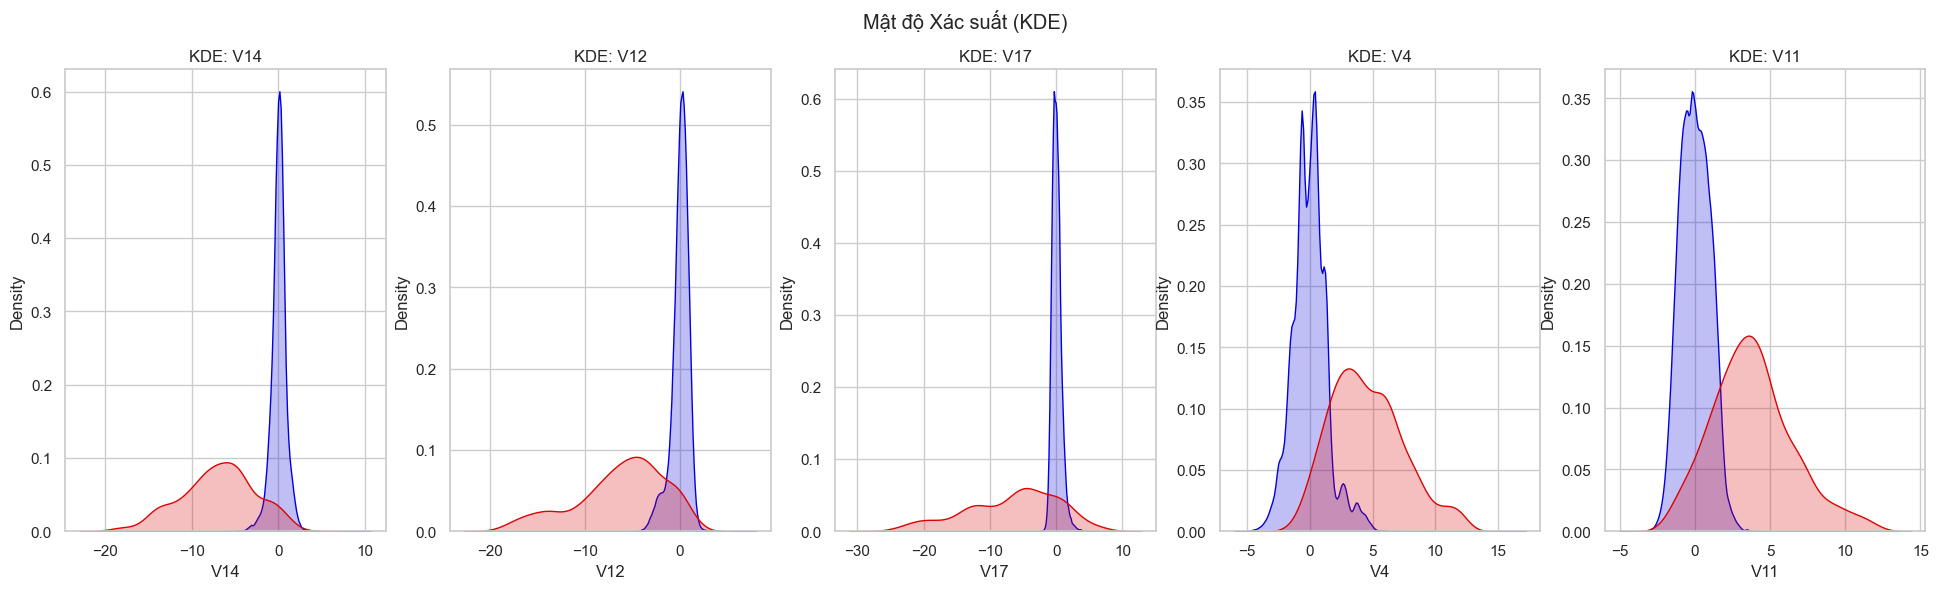

In [43]:
features_to_plot = ['V14', 'V12', 'V17', 'V4', 'V11']

fig, axes = plt.subplots(ncols=len(features_to_plot), figsize=(24, 6))
for i, feature in enumerate(features_to_plot):
    sns.boxplot(x="Class", y=feature, data=df, palette=["#0101DF", "#DF0101"], ax=axes[i])
    axes[i].set_title(f'{feature} vs Class')
plt.suptitle('Biểu đồ Hộp (Boxplot)')
plt.show()

fig, axes = plt.subplots(ncols=len(features_to_plot), figsize=(24, 6))
for i, feature in enumerate(features_to_plot):
    sns.kdeplot(df[feature][df.Class == 0], label="Class 0", color="#0101DF", fill=True, ax=axes[i])
    sns.kdeplot(df[feature][df.Class == 1], label="Class 1", color="#DF0101", fill=True, ax=axes[i])
    axes[i].set_title(f'KDE: {feature}')
plt.suptitle('Mật độ Xác suất (KDE)')
plt.show()
